In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import make_pipeline

In [55]:
null_columns_a = ["life_expectancy", "adult_mortality", "bmi", "polio", "diphtheria", "thinness_10_19_years", "thinness_5_9_years"]
drop_columns = [col for col in null_columns_a if col] # Derived from null_columns_a to remove rows with null values less than 5%
null_columns_b = ["alcohol", "hepatitis_b", "total_expenditure", "gdp", "population", "schooling", "income_composition_of_resources"]
imp_cols = [col for col in null_columns_b if col]
imp_mean_col = ["alcohol", "total_expenditure", "gdp", "population", "income_composition_of_resources"]
imp_median_col = ["hepatitis_b", "schooling"]


In [ ]:
data = (
    pd.read_csv("life_expectancy_data.csv")
    .rename(columns= lambda col: col.strip().lower().replace(" ", "_").replace("-", "_").replace("thinness_1_19_years", "thinness_10_19_years"))
    .dropna(subset = drop_columns, how = "any")
    .assign(avg_thinness = lambda x : x[["thinness_10_19_years", "thinness_5_9_years"]].mean(axis = 1))
    .drop(columns = ["infant_deaths", "country", "thinness_10_19_years", "thinness_5_9_years"]) #Feature Engineering
)
data

In [ ]:
missing_data = data.isnull().sum()
total_obv = data.shape[0]
print(f"Total Sum of Missing Data: {missing_data}")
print(f"Total Number of Observations/Rows:{total_obv}")

In [ ]:
missing_percent = missing_data / total_obv * 100
missing_percent

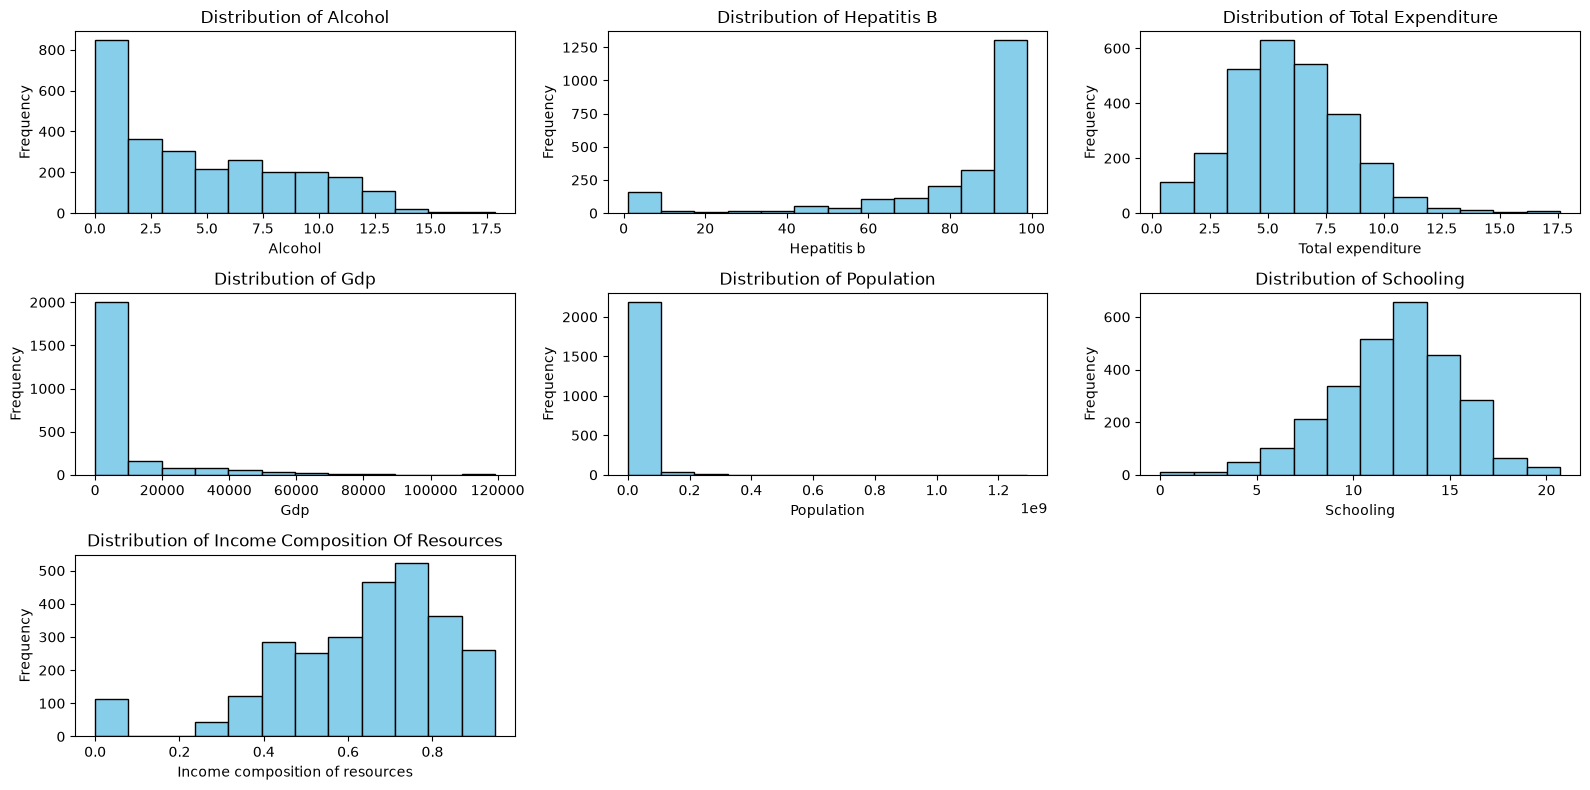

In [27]:
fig, axes = plt.subplots(nrows = 3, ncols = 3, figsize = (16, 8))
axes = axes.flatten()
for i, col in enumerate(imp_cols):
    axes[i].hist(data[col], bins = 12
    , color = "skyblue", edgecolor = "black")
    axes[i].set_title(f"Distribution of {col.capitalize().replace("_", " ").title()}")
    axes[i].set_xlabel(col.capitalize().replace("_", " "))
    axes[i].set_ylabel("Frequency")
for j in range(len(imp_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()    

In [28]:
for col in imp_mean_col:
    mean_val = data[col].mean()
    data[col] = data[col].fillna(mean_val)  

for col in imp_median_col:
    median_val = data[col].median()
    data[col] = data[col].fillna(median_val) 

In [ ]:
num_columns = data.select_dtypes("number")
corr_matrix_cols = (
    num_columns.corr()
)
corr_mask = np.triu(np.ones_like(corr_matrix_cols, dtype = bool))
masked_corr_matrix = corr_matrix_cols.mask(corr_mask)

cleaned_corr_matrix = (
    masked_corr_matrix.unstack()
    .dropna()
    .reset_index()
)
cleaned_corr_matrix.columns = ["Metric 1", "Metric 2", "Correlation"]
cleaned_corr_matrix["Abs_Corr"] = cleaned_corr_matrix["Correlation"].abs()
cleaned_corr_matrix = cleaned_corr_matrix.sort_values(by = "Abs_Corr", ascending = True).drop(columns = ["Abs_Corr"]).reset_index(drop = True)
cleaned_corr_matrix

<Axes: >

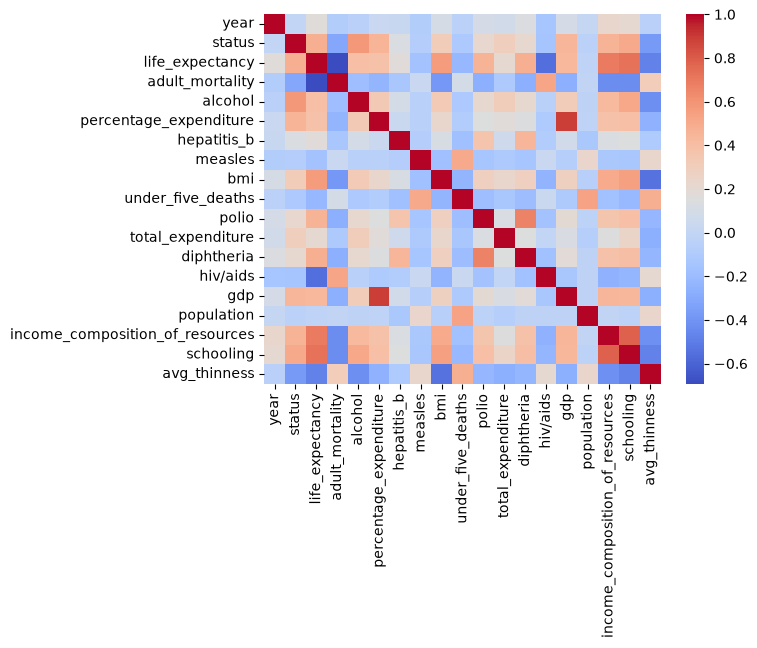

In [30]:
sns.heatmap(data.corr(numeric_only = True), annot = False, cmap = "coolwarm")

In [ ]:
target_var = "life_expectancy"
target_corr = (
    cleaned_corr_matrix[(cleaned_corr_matrix["Metric 1"] == target_var) | (cleaned_corr_matrix["Metric 2"] == target_var)]
    .copy()
    .sort_values(ascending = False, by = "Correlation", key = abs)
    .reset_index(drop = True)
)

target_corr 

In [43]:
target = "life_expectancy"
features = [col for col in data.columns if col not in target]
X = data[features]
y = data[target]

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print(f"Training set: {X_train.shape[0]}")
print(f"Test set: {X_test.shape[0]}")

Training set: 2310
Test set: 578


In [ ]:
#Baseline Mean
target_mean = y_train.mean()
target_pred_baseline = [target_mean] * len(y_test)
baseline_mean = mean_absolute_error(y_test, target_pred_baseline)

#Linear Regressiion Model and OnHotEncoder to encode status
model_lr = make_pipeline(
    OneHotEncoder(drop = "first", handle_unknown = "ignore"),
    LinearRegression()
)

#Fit the Model on Train Dataset
model_lr.fit(X_train, y_train)
target_pred_on_train = model_lr.predict(X_train)

#Generating Predictions Using Train Dataset
mae_train = mean_absolute_error(y_train, target_pred_on_train)
rmse_train = root_mean_squared_error(y_train, target_pred_on_train)
r2_train = r2_score(y_train, target_pred_on_train)

print(f"Baseline Mean: {baseline_mean:.2f}")
print(f"Mean Absolute Error: {mae_train:.4f}")
print(f"Root Mean Squared Eror: {rmse_train:.4f}")
print(f"R Squared: {r2_train:.4f}")

Baseline Mean: 7.74
Mean Absolute Error: 0.0001
Root Mean Squared Eror: 0.0002
R Squared: 1.0000


In [74]:
#Pedict on Test Dataset
target_pred_on_test = model_lr.predict(X_test)

#Generating Predictions Using Test Dataset
mae_test = mean_absolute_error(y_test, target_pred_on_test)
rmse_test = root_mean_squared_error(y_test, target_pred_on_test)
r2_test = r2_score(y_test, target_pred_on_test)

print(f"Baseline Mean: {baseline_mean:.2f}")
print(f"Mean Absolute Error: {mae_test:.4f}")
print(f"Root Mean Squared Eror: {rmse_test:.4f}")
print(f"R Squared: {r2_test:.4f}")

Baseline Mean: 7.74
Mean Absolute Error: 3.5471
Root Mean Squared Eror: 4.7818
R Squared: 0.7467


c:\Users\HP\Desktop\Data Science\project_life_expectancy\venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [81]:
metrics_comparison = pd.DataFrame(
    {
        "Metric": ["MAE", "RMSE", "R2"],
        "Train": [mae_train, rmse_train, r2_train],
        "Test": [mae_test, rmse_test, r2_test]
    }
)
print(metrics_comparison)
print(f"The difference between the train and test RMSE is: {rmse_test - rmse_train:.4f}")

  Metric     Train      Test
0    MAE  0.000146  3.547077
1   RMSE  0.000210  4.781752
2     R2  1.000000  0.746701
The difference between the train and test RMSE is: 4.7815
